In [1]:
# Import the FAIRFluids models
import sys
sys.path.append('/home/sga/Code/FAIRFluids')
from fairfluids.ThermoMLMapping import ThermoMLMapper
from fairfluids import FAIRFluidsDocument
from fairfluids.core.visualization import extract_fairfluids_data, plot_dataframe
from fairfluids.core.functionalities import combine_compounds
from fairfluids import FAIRFluidsDocument, FluidIO, calculate_ratio_of_solvent

# Initialize the converter
converter = ThermoMLMapper()

# Path to the ThermoML XML file
thermoml_path = '/home/sga/Code/FAIRFluids/fairfluids/data/thermoml_xml/spera_et_al_fpe_592_2025_114324.xml'

# Convert a ThermoML XML file to FAIRFluids format
fairfluids_doc = converter.convert_file(thermoml_path)

# The converted document is now ready to use
print(f"✅ Converted {len(fairfluids_doc.compound)} compounds and {len(fairfluids_doc.fluid)} fluids")
print(f"\n📊 Summary:")
print(f"   - Compounds: {[c.compoundID for c in fairfluids_doc.compound]}")
print(f"   - Total fluids: {len(fairfluids_doc.fluid)}")
print(f"   - Total measurements: {sum(len(f.measurement) for f in fairfluids_doc.fluid)}")




=== Filtering Fluid with 1 compounds and 5 measurements ===
✅ Keeping compound: compound_water (non-zero mole fractions)
Final result: 1 compounds, 3 parameters
=== Filtering Fluid with 1 compounds and 5 measurements ===
✅ Keeping compound: compound_water (non-zero mole fractions)
Final result: 1 compounds, 3 parameters
=== Filtering Fluid with 4 compounds and 5 measurements ===
✅ Keeping compound: compound_water (non-zero mole fractions)
✅ Keeping compound: compound_choline (non-zero mole fractions)
✅ Keeping compound: compound_16887006 (non-zero mole fractions)
✅ Keeping compound: compound_glycerol (non-zero mole fractions)
Final result: 4 compounds, 6 parameters
=== Filtering Fluid with 4 compounds and 5 measurements ===
✅ Keeping compound: compound_water (non-zero mole fractions)
✅ Keeping compound: compound_choline (non-zero mole fractions)
✅ Keeping compound: compound_16887006 (non-zero mole fractions)
✅ Keeping compound: compound_glycerol (non-zero mole fractions)
Final result: 

In [2]:
choline_chloride = {    
    "compoundID":"6209",
    "pubChemID":6209,
    "commonName":"Choline Chloride",
    "name_IUPAC":"2-hydroxyethyl(trimethyl)azanium chloride",
    "standard_InChI":"InChI=1S/C5H14NO.ClH/c1-6(2,3)4-5-7;/h7H,4-5H2,1-3H3;1H/q+1;/p-1",
    "standard_InChI_key":"SGMZJAMFXRQCDB-UHFFFAOYSA-M"
}

fairfluids_doc = combine_compounds(fairfluids_doc, old_molecules = [305, 312], new_molecule = 6209)


=== Combining Compounds ===
Old molecules (pubChemIDs): [305, 312]
New molecule (pubChemID): 6209
Found old compound to remove: compound_choline (pubChemID: 305)
Found old compound to remove: compound_16887006 (pubChemID: 312)
Created new compound: compound_cholinechloride
Updated fluid compounds: ['compound_water', 'compound_glycerol', 'compound_cholinechloride']
Added new parameter: parameter_mole_fraction_cholinechloride
Combined mole fractions: ['parameter_mole_fraction_choline', 'parameter_mole_fraction_16887006'] -> 0.033
Combined mole fractions: ['parameter_mole_fraction_choline', 'parameter_mole_fraction_16887006'] -> 0.033
Combined mole fractions: ['parameter_mole_fraction_choline', 'parameter_mole_fraction_16887006'] -> 0.033
Combined mole fractions: ['parameter_mole_fraction_choline', 'parameter_mole_fraction_16887006'] -> 0.033
Combined mole fractions: ['parameter_mole_fraction_choline', 'parameter_mole_fraction_16887006'] -> 0.033
Updated fluid compounds: ['compound_water'

## Extract and Visualize Data

Extract the converted data into a pandas DataFrame for analysis and visualization.


In [3]:
fairfluids_doc   = calculate_ratio_of_solvent(
    doc=fairfluids_doc,
    parameter_id_1="parameter_mole_fraction_glycerol",
    parameter_id_2="parameter_mole_fraction_cholinechloride",
    name="glycerol_cholinechloride",
    compound_id_1="compound_glycerol",
    compound_id_2="compound_cholinechloride",
    precision=1  # Round to 2 decimal places - ensures 2.0 instead of 2.0075...
)

=== Calculating Solvent Ratio: glycerol_cholinechloride ===
Component 1: parameter_mole_fraction_glycerol
Component 2: parameter_mole_fraction_cholinechloride
Processing 92 fluids

--- Processing Fluid 1 ---
Skipping fluid 1: compound_glycerol not in compounds list
Skipping fluid 1: compound_cholinechloride not in compounds list

--- Processing Fluid 2 ---
Skipping fluid 2: compound_glycerol not in compounds list
Skipping fluid 2: compound_cholinechloride not in compounds list

--- Processing Fluid 3 ---
Added new parameter: parameter_solvent_ratio_glycerol_cholinechloride
Associated compounds: ['compound_glycerol', 'compound_cholinechloride']
Measurement 6d83e8c4-d48b-440d-ab1e-3b13ef1cee9f: ratio = 0.067 / 0.033 = 2.0
Added ratio value 2.0 to measurement 6d83e8c4-d48b-440d-ab1e-3b13ef1cee9f
Measurement b0fcb4e3-25de-4322-80ab-4b2d052da857: ratio = 0.067 / 0.033 = 2.0
Added ratio value 2.0 to measurement b0fcb4e3-25de-4322-80ab-4b2d052da857
Measurement b5885fef-a003-4f40-9e41-da8557c5

In [4]:
# Multiply viscosity measurements by 1000 to convert from Pa·s to mPa·s
# WARNING: propValue is not always a float; check type and handle accordingly.

# Demonstration that no viscosity values are changed (dry run)
modified_viscosities = []
for fluid in getattr(fairfluids_doc, "fluid", []):
    for measurement in getattr(fluid, "measurement", []):
        for prop_value in getattr(measurement, "propertyValue", []):
            if getattr(prop_value, "propertyID", "") == "viscosity":
                orig_value = prop_value.propValue
                orig_uncert = prop_value.uncertainty
                # Simulate conversion, but do not modify
                would_convert = False
                try:
                    if prop_value.propValue is not None and isinstance(prop_value.propValue, (float, int, str)):
                        _ = float(prop_value.propValue) * 1000
                        would_convert = True
                    if prop_value.uncertainty is not None and isinstance(prop_value.uncertainty, (float, int, str)):
                        _ = float(prop_value.uncertainty) * 1000
                        would_convert = True
                except Exception as e:
                    print(f"Could not _simulate_ conversion for viscosity: {e}")
                if would_convert:
                    modified_viscosities.append({
                        "fluid": getattr(fluid, "fluidID", None),
                        "original_value": orig_value,
                        "converted_value": orig_value,  # Not actually converted
                        "original_uncertainty": orig_uncert,
                        "converted_uncertainty": orig_uncert  # Not actually converted
                    })

# Debug print for all would-be-modified viscosities
print("🔍 Debug: (Dry run) No viscosity values transformed (Pa·s → mPa·s):")
for mod in modified_viscosities:
    print(f"fluid={mod['fluid']}, value: {mod['original_value']} (no change), uncertainty: {mod['original_uncertainty']} (no change)")

print("ℹ️ No viscosity values transformed. (Dry run only.)")


🔍 Debug: (Dry run) No viscosity values transformed (Pa·s → mPa·s):
ℹ️ No viscosity values transformed. (Dry run only.)


In [5]:
with open('paper_outputs/spera_et_al_fpe_592_2025_114324.json', 'w') as f:
    f.write(fairfluids_doc.model_dump_json(indent=4))



In [9]:
# Extract data from FAIRFluids document to DataFrame
df_data = extract_fairfluids_data(fairfluids_doc)

# Display the extracted data
print(f"Extracted {len(df_data)} data points")
print(df_data.head(10))
df_data.to_csv('df_data.csv', index=False)

df_data[df_data["property_type"] == "viscosity"].head()

Extracted 396 data points
  fluid_compounds  property_type  property_value  uncertainty  temperature  \
0         [water]        density       989.26692     0.132553       313.15   
1         [water]        density       984.23857     0.029222       323.15   
2         [water]        density       978.73098     0.470517       333.15   
3         [water]        density       972.22267     0.368699       343.15   
4         [water]        density       965.13213     0.251989       353.15   
5         [water]  molarEnthalpy   -113162.51340    16.404579       313.15   
6         [water]  molarEnthalpy   -110550.96845     7.783080       323.15   
7         [water]  molarEnthalpy   -107971.66792    30.769541       333.15   
8         [water]  molarEnthalpy   -105389.20995    35.461666       343.15   
9         [water]  molarEnthalpy   -102849.66809    34.538222       353.15   

  mole_fractions                        measurement_id  \
0          [1.0]  40d5a732-7cd1-40bc-851f-f929c3f8dbb8   

,fluid_compounds,property_type,property_value,uncertainty,temperature,mole_fractions,measurement_id,source_doi,Temperature,Mole fraction,...,excessMolarVolume_value,excessMolarVolume_uncertainty,excessMolarEnthalpy_value,excessMolarEnthalpy_uncertainty,diffusionCoefficient_value,diffusionCoefficient_uncertainty,viscosity_value,viscosity_uncertainty,henrysLawConstant_value,henrysLawConstant_uncertainty
340,"[water, glycerol, Choline Chloride]",viscosity,0.181663,0.063329,313.15,"[0.0, 0.667, 0.333]",f8e915d2-d28d-4f0b-b6f1-94e08e6265ca,10.1016/j.fluid.2024.114324,313.15,0.333,...,None,None,None,None,None,None,0.181663,0.063329,None,None
341,"[water, glycerol, Choline Chloride]",viscosity,0.120150,0.014113,323.15,"[0.0, 0.667, 0.333]",15a71432-ace0-436b-add3-76ab02afe321,10.1016/j.fluid.2024.114324,323.15,0.333,...,None,None,None,None,None,None,0.12015,0.014113,None,None
342,"[water, glycerol, Choline Chloride]",viscosity,0.062367,0.005102,333.15,"[0.0, 0.667, 0.333]",a1f08b77-ab52-45f4-a58d-da77ffe8938e,10.1016/j.fluid.2024.114324,333.15,0.333,...,None,None,None,None,None,None,0.062367,0.005102,None,None
343,"[water, glycerol, Choline Chloride]",viscosity,0.042916,0.003059,343.15,"[0.0, 0.667, 0.333]",d80d67a4-eb46-403f-a061-6f6abc13453c,10.1016/j.fluid.2024.114324,343.15,0.333,...,None,None,None,None,None,None,0.042916,0.003059,None,None
344,"[water, glycerol, Choline Chloride]",viscosity,0.031076,0.000876,353.15,"[0.0, 0.667, 0.333]",725102b8-a05c-40ca-a020-b9253246e7a0,10.1016/j.fluid.2024.114324,353.15,0.333,...,None,None,None,None,None,None,0.031076,0.000876,None,None


In [10]:
df_data = extract_fairfluids_data(fairfluids_doc)

# Compute mole_fraction_water column for use in filtering
df_data = df_data.copy()
df_data["mole_fraction_water"] = df_data["mole_fractions"].apply(
    lambda mf: mf[-1] if isinstance(mf, (list, tuple)) and len(mf) > 0 else float('nan')
)

# Ensure mole_fraction_water is 1.0 when [Water] is the only component
def get_water_mole_fraction(row):
    """Get the mole fraction of water from fluid_compounds and mole_fractions."""
    if not isinstance(row["fluid_compounds"], list) or not isinstance(row["mole_fractions"], (list, tuple)):
        return 0.0
    
    # Find the position of water in fluid_compounds
    water_position = -1
    for i, compound in enumerate(row["fluid_compounds"]):
        if isinstance(compound, str) and compound.lower() in ['water', 'h2o']:
            water_position = i
            break
    
    # If water is found and mole_fractions has enough elements, return the mole fraction
    if water_position >= 0 and len(row["mole_fractions"]) > water_position:
        return row["mole_fractions"][water_position]
    else:
        return 0.0

df_data["mole_fraction_water"] = df_data.apply(get_water_mole_fraction, axis=1)

# Apply 0 to mole_fraction_water if only cholinechloride and glycerol is present in fluid_compounds
df_data.loc[
    (df_data["fluid_compounds"].apply(
        lambda comps: isinstance(comps, list)
        and len(comps) == 2
        and set(comps) == set(["Choline Chloride", "Glycerol"])
    )),
    "mole_fraction_water"
] = 0.0

# Additional dataframe for just [Choline Chloride, Glycerol]
df_reline_just_cc_gly = df_data[
    df_data["fluid_compounds"].apply(
        lambda comps: isinstance(comps, list)
        and len(comps) == 2
        and set(comps) == set(["Choline Chloride", "Glycerol"])
    )
]

# Filter for ratio == 2 OR (molefractions has water == 1)
df_data_ratio_or_pure_water = df_data[
    (df_data["Solvent: Amount ratio of component to other component of binary solvent"] == 2)
    | (df_data["mole_fraction_water"] == 1.0)
    | (df_data["mole_fraction_water"] == 0.0)  # include the newly set 0.0 rows
]

# Sort by the water mole fraction, descending
combined_df = df_data_ratio_or_pure_water.sort_values(
    by="mole_fraction_water", ascending=False
)
df_data_ratio_or_pure_water.head()



,fluid_compounds,property_type,property_value,uncertainty,temperature,mole_fractions,measurement_id,source_doi,Temperature,Mole fraction,...,excessMolarVolume_value,excessMolarVolume_uncertainty,excessMolarEnthalpy_value,excessMolarEnthalpy_uncertainty,diffusionCoefficient_value,diffusionCoefficient_uncertainty,viscosity_value,viscosity_uncertainty,henrysLawConstant_value,henrysLawConstant_uncertainty
0,[water],density,989.26692,0.132553,313.15,[1.0],40d5a732-7cd1-40bc-851f-f929c3f8dbb8,10.1016/j.fluid.2024.114324,313.15,1.0,...,None,None,None,None,None,None,None,None,None,None
1,[water],density,984.23857,0.029222,323.15,[1.0],456aa8c4-3bc7-4a65-90d0-9e6c007116cc,10.1016/j.fluid.2024.114324,323.15,1.0,...,None,None,None,None,None,None,None,None,None,None
2,[water],density,978.73098,0.470517,333.15,[1.0],c4b1b1c0-b85f-46b3-91de-2246394e3bca,10.1016/j.fluid.2024.114324,333.15,1.0,...,None,None,None,None,None,None,None,None,None,None
3,[water],density,972.22267,0.368699,343.15,[1.0],b61b0f88-ec51-480c-8398-0a07ee291824,10.1016/j.fluid.2024.114324,343.15,1.0,...,None,None,None,None,None,None,None,None,None,None
4,[water],density,965.13213,0.251989,353.15,[1.0],4ad7e8d2-16bc-476b-980c-1448994e5b48,10.1016/j.fluid.2024.114324,353.15,1.0,...,None,None,None,None,None,None,None,None,None,None


NameError: name 'save_plot_as_svg' is not defined

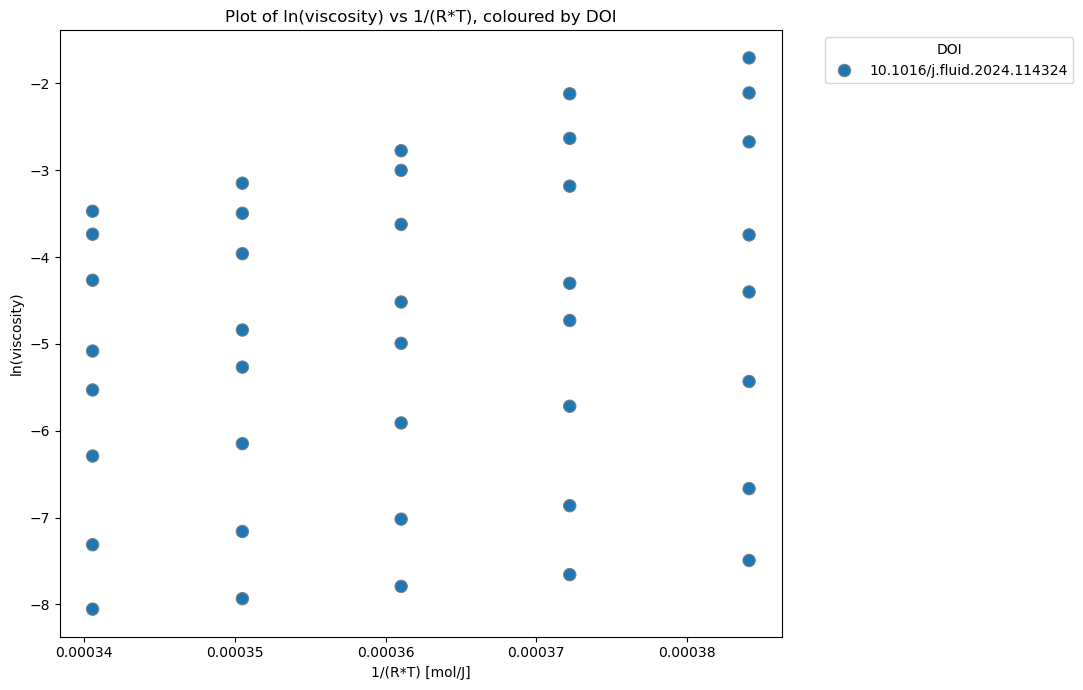

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make sure required columns exist
required_cols = ["viscosity_value", "temperature", "source_doi", "mole_fraction_water"]
for col in required_cols:
    if col not in df_data_ratio_or_pure_water.columns:
        raise ValueError(f"Column '{col}' not found in dataframe.")

# Filter out rows with missing data
plot_df = df_data_ratio_or_pure_water[df_data_ratio_or_pure_water["viscosity_value"].notnull() & df_data_ratio_or_pure_water["temperature"].notnull() & df_data_ratio_or_pure_water["source_doi"].notnull()]

# Calculate ln(viscosity) and 1/RT (Kelvin)
# Use R = 8.314 J/(mol*K), but since it's unitless vs. 1/K, you can leave as 1/T or explicitly use 1/(R*T)
R = 8.314 # J/(mol*K)
plot_df = plot_df.copy()
plot_df["inv_RT"] = 1 / (R * plot_df["temperature"].astype(float))
plot_df["ln_viscosity"] = np.log(plot_df["viscosity_value"].astype(float))

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=plot_df,
    x="inv_RT",
    y="ln_viscosity",
    hue="source_doi",
    palette='tab20',
    s=80,
    edgecolor='gray'
)
plt.title('Plot of ln(viscosity) vs 1/(R*T), coloured by DOI')
plt.xlabel('1/(R*T) [mol/J]')
plt.ylabel('ln(viscosity)')
plt.legend(title="DOI", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
save_plot_as_svg()
plt.show()


In [ ]:
# Import der wiederverwendbaren Plot-Speicherfunktion
from fairfluids.core.plot_utils import save_plot_as_svg


/tmp/ipykernel_8010/3348774472.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', N)


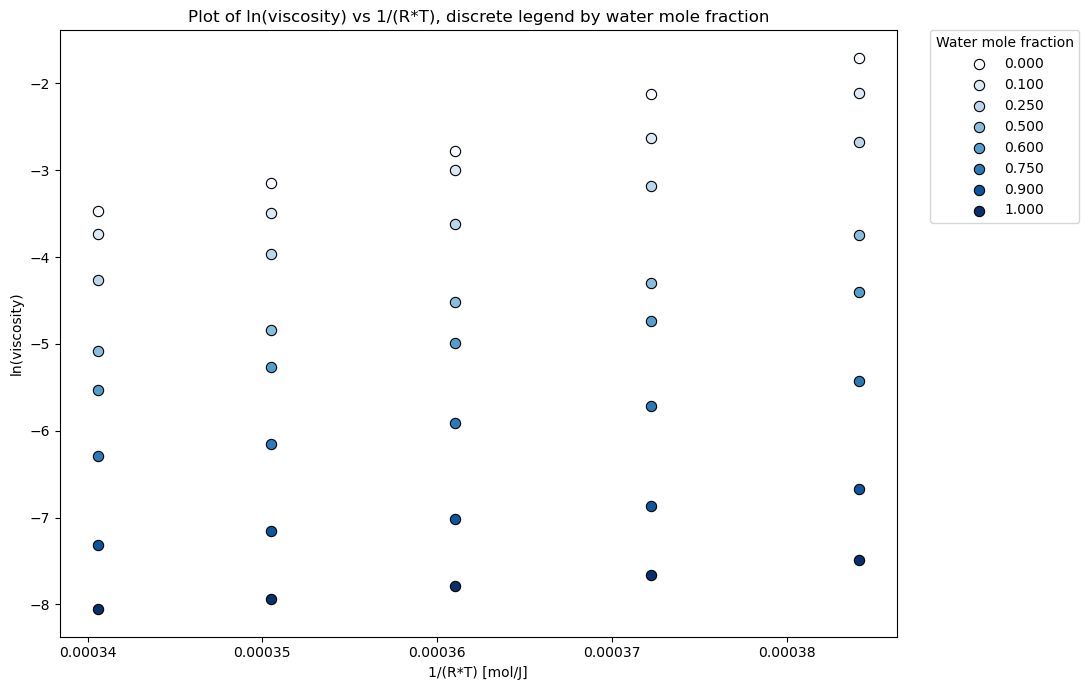

All linear fit activation energies by water mole fraction:


,water_mole_fraction,activation_energy
0,0.00,42029.324327
1,0.10,37944.135877
2,0.25,36568.253101
3,0.50,29649.374056
4,0.60,25702.918365
5,0.75,19799.898023
6,0.90,14635.867659
7,1.00,12864.252347


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from scipy.stats import linregress

# Make sure required columns exist
required_cols = ["viscosity_value", "temperature", "source_doi", "mole_fraction_water"]
for col in required_cols:
    if col not in df_data_ratio_or_pure_water.columns:
        raise ValueError(f"Column '{col}' not found in dataframe.")

# Fill missing/None values in mole_fraction_water with 0
df_data_ratio_or_pure_water = df_data_ratio_or_pure_water.copy()
df_data_ratio_or_pure_water["mole_fraction_water"] = (
    df_data_ratio_or_pure_water["mole_fraction_water"]
    .fillna(0)
    .apply(lambda x: 0 if x is None else x)
)

# Filter out rows with missing data
plot_df = df_data_ratio_or_pure_water[
    df_data_ratio_or_pure_water["viscosity_value"].notnull() &
    df_data_ratio_or_pure_water["temperature"].notnull() &
    df_data_ratio_or_pure_water["source_doi"].notnull()
].copy()

# Calculate ln(viscosity) and 1/(R*T)
R = 8.314  # J/(mol*K)
plot_df["inv_RT"] = 1 / (R * plot_df["temperature"].astype(float))
plot_df["ln_viscosity"] = np.log(plot_df["viscosity_value"].astype(float))

# Use mole_fraction_water to color the water amount
plot_df["water_mole_fraction"] = plot_df["mole_fraction_water"].astype(float)

# We'll use unique discrete values for water mole fraction as hue
plot_df["water_mole_fraction_rounded"] = plot_df["water_mole_fraction"].round(3)
discrete_mole_fractions = np.sort(plot_df["water_mole_fraction_rounded"].unique())

# Set up colormap: Blues colormap, N bins = number of unique mole fractions
N = len(discrete_mole_fractions)
cmap = cm.get_cmap('Blues', N)
color_dict = {mf: cmap(i) for i, mf in enumerate(discrete_mole_fractions)}

plt.figure(figsize=(11,7))
ax = plt.gca()

# Scatter points for each discrete fraction, so legend can be discrete
for i, mf in enumerate(discrete_mole_fractions):
    subset = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    ax.scatter(
        subset["inv_RT"], 
        subset["ln_viscosity"], 
        color=color_dict[mf],
        s=55, 
        edgecolor='black',
        linewidth=0.8,
        label=f"{mf:.3f}"
    )

# Linear fit and store slopes per discrete water content
slope_results = []
for mf in discrete_mole_fractions:
    group = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    if len(group) >= 2:
        x = group["inv_RT"].values
        y = group["ln_viscosity"].values
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        xfit = np.linspace(x.min(), x.max(), 50)
        yfit = intercept + slope * xfit
        # Optional: plot the fits in same color, commented out for clarity
        # ax.plot(xfit, yfit, linestyle='--', linewidth=2, color=color_dict[mf])
        mf_tuple = tuple(group["mole_fractions"].iloc[0]) if "mole_fractions" in group.columns and isinstance(group["mole_fractions"].iloc[0], (list, tuple)) else group["mole_fractions"].iloc[0] if "mole_fractions" in group.columns else None
        slope_results.append({
            "mole_fractions": mf_tuple,
            "water_mole_fraction": float(mf),
            "slope": slope
        })

# Make discrete legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
lgd = ax.legend(by_label.values(), by_label.keys(), title="Water mole fraction", bbox_to_anchor=(1.04, 1), loc='upper left', borderaxespad=0.)

plt.title('Plot of ln(viscosity) vs 1/(R*T), discrete legend by water mole fraction')
plt.xlabel('1/(R*T) [mol/J]')
plt.ylabel('ln(viscosity)')
plt.tight_layout()
save_plot_as_svg()
plt.show()

import pandas as pd
activation_energy_df = pd.DataFrame(slope_results)
activation_energy_df = activation_energy_df.rename(columns={'slope': 'activation_energy'})
print("All linear fit activation energies by water mole fraction:")
display(activation_energy_df[["water_mole_fraction", "activation_energy"]])


## Filter and Plot ln(viscosity) vs 1/RT

Filter data for "Amount ratio of solute to solvent == 2" and plot ln(viscosity) over 1/RT.


/tmp/ipykernel_8010/2284505760.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', N)


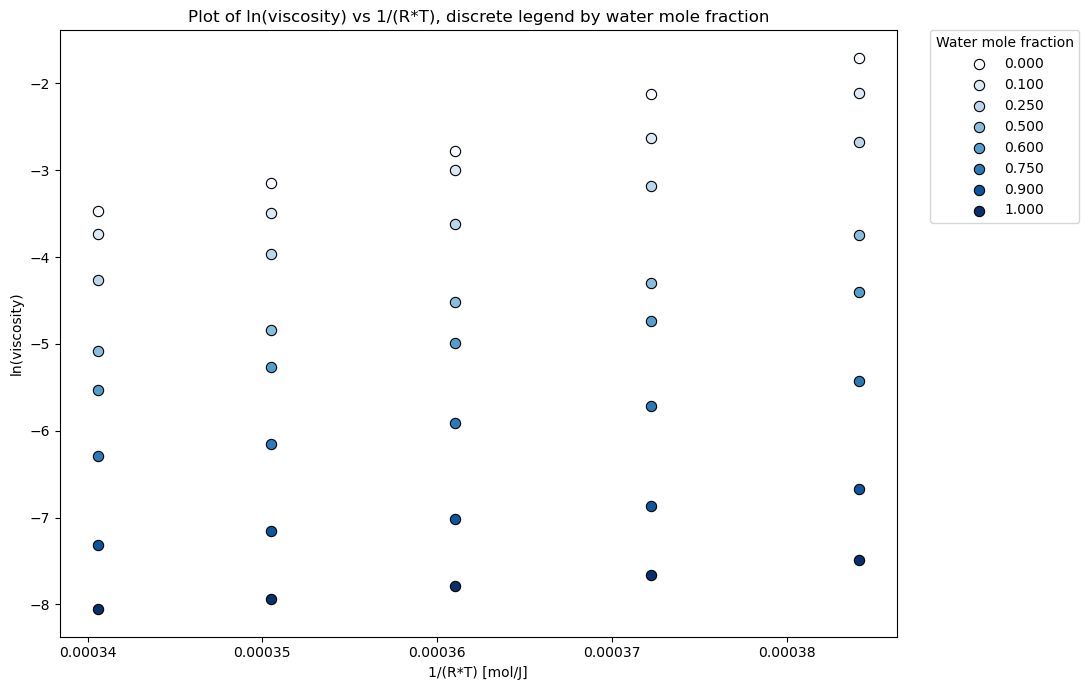

All linear fit activation energies by water mole fraction and source DOI, including ordinate and statistic:


,water_mole_fraction,activation_energy,source_doi,ordinate,statistic
0,0.00,42029.324327,10.1016/j.fluid.2024.114324,-17.845349,0.994708
1,0.10,37944.135877,10.1016/j.fluid.2024.114324,-16.718555,0.996410
2,0.25,36568.253101,10.1016/j.fluid.2024.114324,-16.767117,0.997234
3,0.50,29649.374056,10.1016/j.fluid.2024.114324,-15.220454,0.989051
4,0.60,25702.918365,10.1016/j.fluid.2024.114324,-14.280539,0.999734
5,0.75,19799.898023,10.1016/j.fluid.2024.114324,-13.060908,0.997098
6,0.90,14635.867659,10.1016/j.fluid.2024.114324,-12.297098,0.999315
7,1.00,12864.252347,10.1016/j.fluid.2024.114324,-12.438768,0.999787


Saved activation energy data to 'df_data_ratio_or_pure_water_filtered.csv'


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from scipy.stats import linregress

# Make sure required columns exist
required_cols = [
    "viscosity_value", 
    "temperature", 
    "source_doi", 
    "mole_fraction_water",
    "Solvent: Amount ratio of component to other component of binary solvent"
]
for col in required_cols:
    if col not in df_data_ratio_or_pure_water.columns:
        raise ValueError(f"Column '{col}' not found in dataframe.")

# Filter on solvent ratio: keep rows where ratio <=2 or ratio is NaN (missing/None)
df_data_ratio_or_pure_water_filtered = df_data_ratio_or_pure_water[
    (df_data_ratio_or_pure_water["Solvent: Amount ratio of component to other component of binary solvent"].isna()) |
    (df_data_ratio_or_pure_water["Solvent: Amount ratio of component to other component of binary solvent"] <= 2)
].copy()

# Fill missing/None values in mole_fraction_water with 0
df_data_ratio_or_pure_water_filtered["mole_fraction_water"] = (
    df_data_ratio_or_pure_water_filtered["mole_fraction_water"]
    .fillna(0)
    .apply(lambda x: 0 if x is None else x)
)

# Clean for missing values in variables used
plot_df = df_data_ratio_or_pure_water_filtered[
    df_data_ratio_or_pure_water_filtered["viscosity_value"].notnull() &
    df_data_ratio_or_pure_water_filtered["temperature"].notnull() &
    df_data_ratio_or_pure_water_filtered["source_doi"].notnull()
].copy()

# Calculate ln(viscosity) and 1/(R*T)
R = 8.314  # J/(mol*K)
plot_df["inv_RT"] = 1 / (R * plot_df["temperature"].astype(float))
plot_df["ln_viscosity"] = np.log(plot_df["viscosity_value"].astype(float))

# Use mole_fraction_water to color the water amount
plot_df["water_mole_fraction"] = plot_df["mole_fraction_water"].astype(float)

# We'll use unique discrete values for water mole fraction as hue
plot_df["water_mole_fraction_rounded"] = plot_df["water_mole_fraction"].round(3)
discrete_mole_fractions = np.sort(plot_df["water_mole_fraction_rounded"].unique())

# Set up colormap: Blues colormap, N bins = number of unique mole fractions
N = len(discrete_mole_fractions)
cmap = cm.get_cmap('Blues', N)
color_dict = {mf: cmap(i) for i, mf in enumerate(discrete_mole_fractions)}

plt.figure(figsize=(11,7))
ax = plt.gca()

# Scatter points for each discrete fraction, so legend can be discrete
for i, mf in enumerate(discrete_mole_fractions):
    subset = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    ax.scatter(
        subset["inv_RT"], 
        subset["ln_viscosity"], 
        color=color_dict[mf],
        s=55, 
        edgecolor='black',
        linewidth=0.8,
        label=f"{mf:.3f}"
    )

# Linear fit and store slopes per discrete water content, including source_doi
slope_results = []
for mf in discrete_mole_fractions:
    group = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    # For each unique source_doi in this water content, do a fit for that subset
    for doi in group["source_doi"].unique():
        doi_group = group[group["source_doi"] == doi]
        if len(doi_group) >= 2:
            x = doi_group["inv_RT"].values
            y = doi_group["ln_viscosity"].values
            slope, intercept, r_value, p_value, std_err = linregress(x, y)
            xfit = np.linspace(x.min(), x.max(), 50)
            yfit = intercept + slope * xfit
            # Optionally: plot fits per color, commented
            # ax.plot(xfit, yfit, linestyle='--', linewidth=2, color=color_dict[mf])
            mf_tuple = (tuple(doi_group["mole_fractions"].iloc[0]) if "mole_fractions" in doi_group.columns and isinstance(doi_group["mole_fractions"].iloc[0], (list, tuple)) 
                        else doi_group["mole_fractions"].iloc[0] if "mole_fractions" in doi_group.columns else None)
            slope_results.append({
                "mole_fractions": mf_tuple,
                "water_mole_fraction": float(mf),
                "slope": slope,
                "source_doi": doi,
                "ordinate": intercept,
                "statistic": r_value
            })

# Make discrete legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
lgd = ax.legend(by_label.values(), by_label.keys(), title="Water mole fraction", bbox_to_anchor=(1.04, 1), loc='upper left', borderaxespad=0.)

plt.title('Plot of ln(viscosity) vs 1/(R*T), discrete legend by water mole fraction')
plt.xlabel('1/(R*T) [mol/J]')
plt.ylabel('ln(viscosity)')
plt.tight_layout()
save_plot_as_svg()
plt.show()

import pandas as pd
activation_energy_df = pd.DataFrame(slope_results)
# Rename for clarity
activation_energy_df = activation_energy_df.rename(columns={'slope': 'activation_energy'})
# Ensure 'ordinate' and 'statistic' columns are present (they are, see above)
print("All linear fit activation energies by water mole fraction and source DOI, including ordinate and statistic:")
display(activation_energy_df[["water_mole_fraction", "activation_energy", "source_doi", "ordinate", "statistic"]])

activation_energy_df['measurement'] = 'simulated'
activation_energy_df.to_csv('activation_energy_results.csv', index=False)
activation_energy_df


# Add a column called 'measured' and fill it with 'measured'
df_data_ratio_or_pure_water_filtered['measured'] = 'simulated'

# Multiply viscosity_value by 1000 before saving
if 'viscosity_value' in df_data_ratio_or_pure_water_filtered.columns:
    df_data_ratio_or_pure_water_filtered['viscosity_value'] = df_data_ratio_or_pure_water_filtered['viscosity_value']

# Save the activation energy data to CSV
df_data_ratio_or_pure_water_filtered.to_csv('df_data_ratio_or_pure_water_filtered.csv', index=False)
print("Saved activation energy data to 'df_data_ratio_or_pure_water_filtered.csv'")

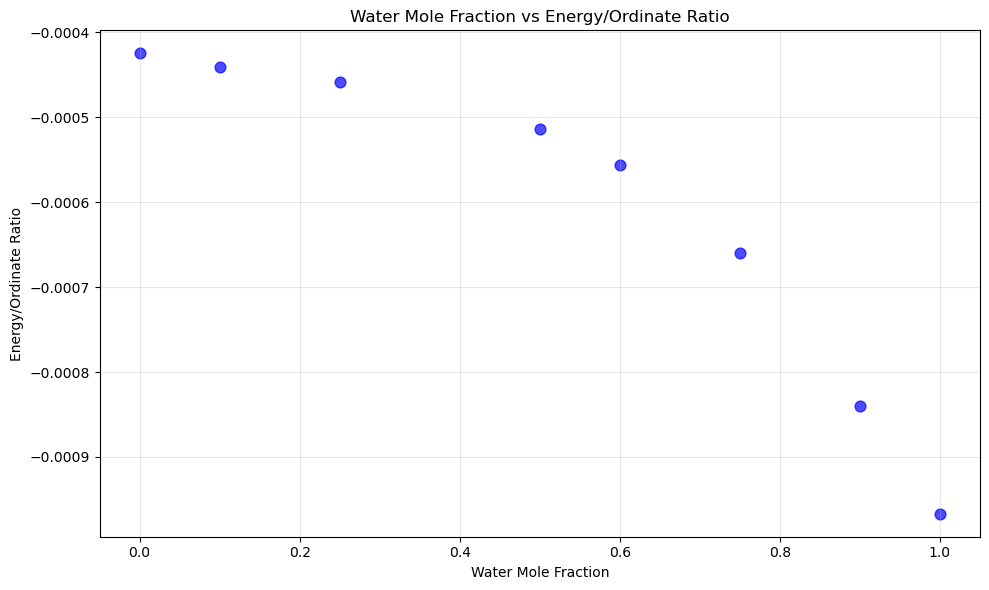

In [ ]:
# Calculate the ratio between activation_energy and ordinate
activation_energy_df['energy_ordinate_ratio'] = activation_energy_df['ordinate'] / (activation_energy_df['activation_energy'])

activation_energy_df

# Plot water_mole_fraction vs energy_ordinate_ratio
plt.figure(figsize=(10, 6))
plt.scatter(activation_energy_df['water_mole_fraction'], activation_energy_df['energy_ordinate_ratio'], 
           alpha=0.7, s=60, color='blue')
plt.xlabel('Water Mole Fraction')
plt.ylabel('Energy/Ordinate Ratio')
plt.title('Water Mole Fraction vs Energy/Ordinate Ratio')
plt.grid(True, alpha=0.3)
plt.tight_layout()
save_plot_as_svg()
plt.show()


## Save the Converted Document

Save the FAIRFluids document to a JSON file.


In [ ]:
# Save the model to a JSON file
import os
output_dir = '/home/sga/Code/FAIRFluids/Workflows/outputs'
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'ThermoML_converted.json')
with open(output_path, 'w') as f:
    f.write(fairfluids_doc.model_dump_json(indent=4))
    
print(f"📁 Output saved to: {output_path}")


📁 Output saved to: /home/sga/Code/FAIRFluids/Workflows/outputs/ThermoML_converted.json


## Visualize the Data

Create visualizations of the converted data to verify the conversion and explore the data.


In [ ]:
# Visualize data from all XML files
import os
import matplotlib.pyplot as plt

xml_dir = '/home/sga/Code/FAIRFluids/fairfluids/data/thermoml_xml'
xml_files = sorted([f for f in os.listdir(xml_dir) if f.endswith('.xml')])

print(f"Processing {len(xml_files)} XML files for visualization...\n")

# Collect all data from all files
all_docs = []

for xml_file in xml_files:
    xml_path = os.path.join(xml_dir, xml_file)
    try:
        converter = ThermoMLMapper()
        doc = converter.convert_file(xml_path)
        all_docs.append(doc)
        print(f"✅ {xml_file}: {len(doc.compound)} compounds, {len(doc.fluid)} fluids")
    except Exception as e:
        print(f"❌ {xml_file}: Error - {str(e)[:80]}")

if all_docs:
    # Extract data from all documents
    all_df = extract_fairfluids_data(all_docs)
    
    print(f"\n📊 Total data points: {len(all_df)}")
    print(f"Available property types: {sorted(all_df['property_type'].unique())}")
    
    # Create visualizations for each property type that has data
    property_types = sorted(all_df['property_type'].unique())
    
    # Create output directory for plots
    plot_dir = '/home/sga/Code/FAIRFluids/Workflows/outputs/plots'
    os.makedirs(plot_dir, exist_ok=True)
    
    # Plot each property type vs temperature
    for prop_type in property_types:
        prop_df = all_df[all_df['property_type'] == prop_type].copy()
        
        if len(prop_df) == 0:
            continue
            
        # Determine the value column name
        value_col = f"{prop_type}_value"
        if value_col not in prop_df.columns:
            value_col = 'property_value'
        
        if value_col not in prop_df.columns or 'temperature' not in prop_df.columns:
            print(f"⚠️  Skipping {prop_type}: missing required columns")
            continue
        
        # Filter out None/NaN values
        plot_df = prop_df.dropna(subset=[value_col, 'temperature'])
        
        if len(plot_df) == 0:
            print(f"⚠️  Skipping {prop_type}: no valid data points")
            continue
        
        print(f"\n📈 Plotting {prop_type} ({len(plot_df)} data points)...")
        
        try:
            # Determine composition column for coloring/grouping
            group_by_col = None
            if 'mole_fractions_rounded' in plot_df.columns:
                unique_compositions = plot_df['mole_fractions_rounded'].nunique()
                if unique_compositions > 1 and unique_compositions <= 15:  # Limit to avoid too many colors
                    group_by_col = 'mole_fractions_rounded'
            elif 'fluid_compounds' in plot_df.columns:
                # Convert fluid_compounds to string for grouping
                plot_df['fluid_compounds_str'] = plot_df['fluid_compounds'].apply(str)
                unique_compounds = plot_df['fluid_compounds_str'].nunique()
                if unique_compounds > 1 and unique_compounds <= 15:
                    group_by_col = 'fluid_compounds_str'
            
            # Create plot with coloring by composition
            if group_by_col:
                fig = plot_dataframe(
                    plot_df,
                    x_axis='temperature',
                    y_axis=value_col,
                    group_by=group_by_col,
                    title=f'{prop_type.replace("_", " ").title()} vs Temperature (colored by composition)',
                    figsize=(14, 8)
                )
            else:
                fig = plot_dataframe(
                    plot_df,
                    x_axis='temperature',
                    y_axis=value_col,
                    title=f'{prop_type.replace("_", " ").title()} vs Temperature',
                    figsize=(12, 8)
                )
            
            # Save plot
            safe_prop_name = prop_type.replace('/', '_').replace(' ', '_')
            plot_path = os.path.join(plot_dir, f'{safe_prop_name}_vs_temperature.png')
            fig.savefig(plot_path, dpi=300, bbox_inches='tight')
            plt.close(fig)
            print(f"   💾 Saved to: {plot_path}")
            
        except Exception as e:
            print(f"   ❌ Error plotting {prop_type}: {str(e)[:100]}")
    
    print(f"\n✅ Visualization complete! Plots saved to: {plot_dir}")
        
else:
    print("❌ No documents were successfully converted.")


Processing 16 XML files for visualization...

=== Filtering Fluid with 2 compounds and 14 measurements ===
✅ Keeping compound: compound_glycerol (non-zero mole fractions)
✅ Keeping compound: compound_cholinechloride (non-zero mole fractions)
Final result: 2 compounds, 5 parameters
=== Filtering Fluid with 2 compounds and 14 measurements ===
✅ Keeping compound: compound_glycerol (non-zero mole fractions)
✅ Keeping compound: compound_cholinechloride (non-zero mole fractions)
Final result: 2 compounds, 5 parameters
=== Filtering Fluid with 2 compounds and 14 measurements ===
✅ Keeping compound: compound_glycerol (non-zero mole fractions)
✅ Keeping compound: compound_tetramethylammoniumchloride (non-zero mole fractions)
Final result: 2 compounds, 5 parameters
=== Filtering Fluid with 2 compounds and 14 measurements ===
✅ Keeping compound: compound_glycerol (non-zero mole fractions)
✅ Keeping compound: compound_tetramethylammoniumchloride (non-zero mole fractions)
Final result: 2 compounds,

In [ ]:
# Read in the activation energy results files
import pandas as pd

# Read the measured activation energy results
try:
    activation_energy_measured = pd.read_csv('activation_energy_results_measured.csv')
    print("✅ Successfully loaded activation_energy_results_measured.csv")
    print(f"   Shape: {activation_energy_measured.shape}")
    print(f"   Columns: {list(activation_energy_measured.columns)}")
    print("\nFirst few rows:")
    print(activation_energy_measured.head())
except FileNotFoundError:
    print("❌ activation_energy_results_measured.csv not found")
    activation_energy_measured = None
except Exception as e:
    print(f"❌ Error loading activation_energy_results_measured.csv: {e}")
    activation_energy_measured = None

print("\n" + "="*50 + "\n")

# Read the activation energy results
try:
    activation_energy_results = pd.read_csv('activation_energy_results.csv')
    print("✅ Successfully loaded activation_energy_results.csv")
    print(f"   Shape: {activation_energy_results.shape}")
    print(f"   Columns: {list(activation_energy_results.columns)}")
    print("\nFirst few rows:")
    print(activation_energy_results.head())
except FileNotFoundError:
    print("❌ activation_energy_results.csv not found")
    activation_energy_results = None
except Exception as e:
    print(f"❌ Error loading activation_energy_results.csv: {e}")
    activation_energy_results = None


✅ Successfully loaded activation_energy_results_measured.csv
   Shape: (19, 8)
   Columns: ['mole_fractions', 'water_mole_fraction', 'activation_energy', 'source_doi', 'ordinate', 'statistic', 'color', 'measurement']

First few rows:
                     mole_fractions  water_mole_fraction  activation_energy  \
0  (0.333333333333, 0.666666666667)                  0.0       46748.108736   
1  (0.333333333333, 0.666666666667)                  0.0       37401.010918   
2  (0.333333333333, 0.666666666667)                  0.0       43647.834764   
3  (0.333333333333, 0.666666666667)                  0.0       45099.537048   
4  (0.333333333333, 0.666666666667)                  0.0       41925.535292   

                     source_doi   ordinate  statistic    color measurement  
0     10.1016/j.jct.2018.07.031 -26.846532   0.998271  #8fe388    measured  
1  10.1016/j.molliq.2015.11.032 -23.168710   0.996212  #d00000    measured  
2            10.1039/c1cp22554e -25.906119   0.999017  #5d2e

In [ ]:
# Combine the activation energy datasets
if activation_energy_measured is not None and activation_energy_results is not None:
    print("🔄 Combining activation energy datasets...")
    
    # Add a source column to distinguish between datasets
    activation_energy_measured_copy = activation_energy_measured.copy()
    activation_energy_results_copy = activation_energy_results.copy()
    
    activation_energy_measured_copy['data_source'] = 'measured'
    activation_energy_results_copy['data_source'] = 'simulated'
    
    # Combine the datasets
    combined_activation_energy = pd.concat([
        activation_energy_measured_copy, 
        activation_energy_results_copy
    ], ignore_index=True)
    
    print("✅ Successfully combined activation energy datasets")
    print(f"   Combined shape: {combined_activation_energy.shape}")
    print(f"   Measured data points: {len(activation_energy_measured_copy)}")
    print(f"   Simulated data points: {len(activation_energy_results_copy)}")
    
    print("\nCombined dataset preview:")
    print(combined_activation_energy.head(10))
    
elif activation_energy_measured is not None:
    print("⚠️  Only measured data available - using as combined dataset")
    combined_activation_energy = activation_energy_measured.copy()
    combined_activation_energy['data_source'] = 'measured'
    
elif activation_energy_results is not None:
    print("⚠️  Only simulated data available - using as combined dataset")
    combined_activation_energy = activation_energy_results.copy()
    combined_activation_energy['data_source'] = 'simulated'
    
else:
    print("❌ No activation energy data available to combine")
    combined_activation_energy = None



🔄 Combining activation energy datasets...
✅ Successfully combined activation energy datasets
   Combined shape: (27, 9)
   Measured data points: 19
   Simulated data points: 8

Combined dataset preview:
                               mole_fractions  water_mole_fraction  \
0            (0.333333333333, 0.666666666667)                0.000   
1            (0.333333333333, 0.666666666667)                0.000   
2            (0.333333333333, 0.666666666667)                0.000   
3            (0.333333333333, 0.666666666667)                0.000   
4            (0.333333333333, 0.666666666667)                0.000   
5     (0.297333333333, 0.594666666667, 0.108)                0.108   
6    (0.253966666667, 0.507933333333, 0.2381)                0.238   
7  (0.24937655859, 0.49625935141, 0.25436409)                0.254   
8    (0.219166666667, 0.438333333333, 0.3425)                0.342   
9    (0.199266666667, 0.398533333333, 0.4022)                0.402   

   activation_energy      

<>:53: SyntaxWarning: invalid escape sequence '\c'
<>:53: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_8010/1989257413.py:53: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel('$\chi_W$ / Water Mole Fraction', fontsize=12)


📊 Plotting combined activation energy data...

📊 Line through means statistics:
   Mean at water mole fraction 0: 42808.6 J/mol
   Mean at water mole fraction 1: 13411.1 J/mol
   Slope: -29397.5 J/mol per unit mole fraction


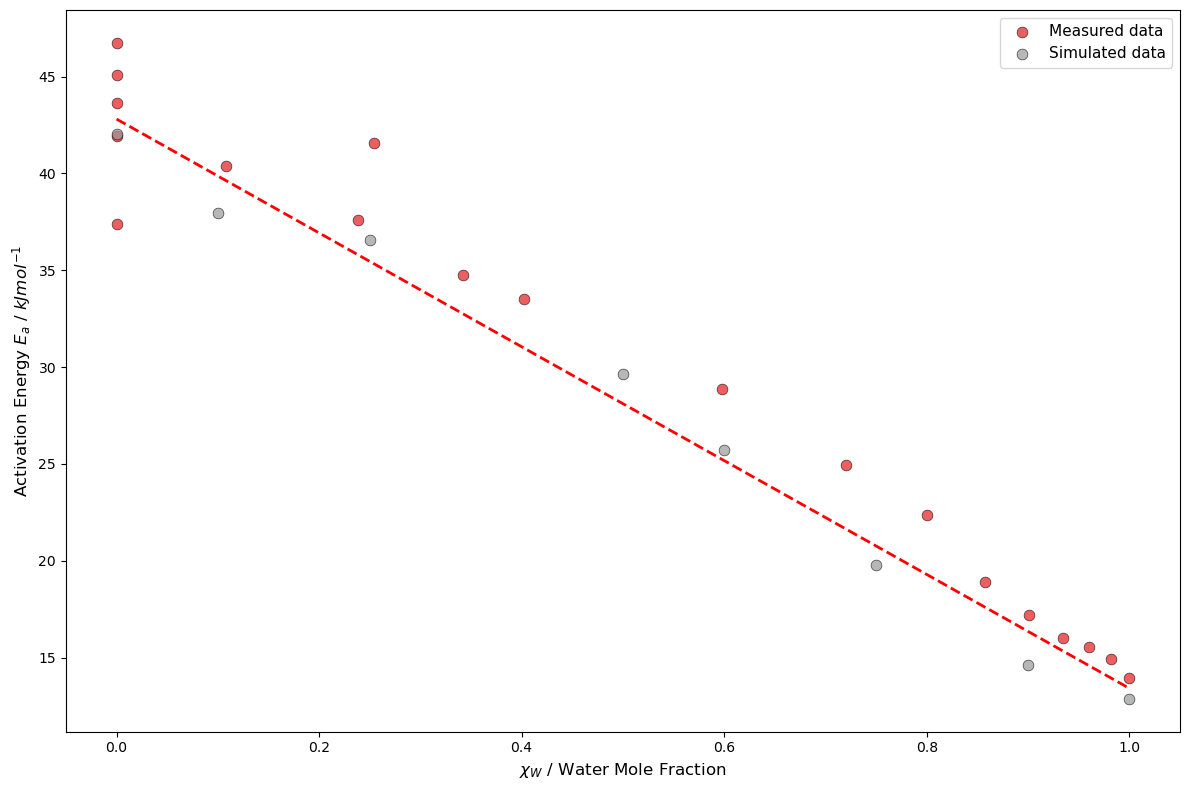


📈 Combined dataset statistics:
   Total data points: 27
   Water mole fraction range: 0.000 - 1.000
   Activation energy range: 12.9 - 46.7 kJ/mol
   Measured data: 19 points
   Simulated data: 8 points


In [ ]:
# Plot combined activation energy data
if combined_activation_energy is not None:
    print("📊 Plotting combined activation energy data...")
    
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Get unique data sources and create colors
    data_sources = combined_activation_energy['data_source'].unique()
    colors = plt.cm.Set1(np.linspace(0, 1, len(data_sources)))
    
    # Plot each data source separately
    for i, source in enumerate(data_sources):
        source_data = combined_activation_energy[combined_activation_energy['data_source'] == source]
        
        ax.scatter(
            source_data['water_mole_fraction'], 
            source_data['activation_energy'] / 1000,  # Convert J/mol to kJ/mol
            c=[colors[i]], 
            label=f'{source.capitalize()} data',
            alpha=0.7,
            s=60,
            edgecolors='black',
            linewidth=0.5
        )
    
    # Calculate means at water mole fraction 0 and 1
    data_at_0 = combined_activation_energy[combined_activation_energy['water_mole_fraction'] == 0.0]
    data_at_1 = combined_activation_energy[combined_activation_energy['water_mole_fraction'] == 1.0]
    
    if len(data_at_0) > 0 and len(data_at_1) > 0:
        mean_at_0 = data_at_0['activation_energy'].mean()
        mean_at_1 = data_at_1['activation_energy'].mean()
        
        # Draw dashed line through the means (no legend)
        ax.plot([0, 1], [mean_at_0 / 1000, mean_at_1 / 1000], 'r--', linewidth=2)  # Convert to kJ/mol
        
        # Calculate slope for reporting
        slope = mean_at_1 - mean_at_0
        
        print(f"\n📊 Line through means statistics:")
        print(f"   Mean at water mole fraction 0: {mean_at_0:.1f} J/mol")
        print(f"   Mean at water mole fraction 1: {mean_at_1:.1f} J/mol")
        print(f"   Slope: {slope:.1f} J/mol per unit mole fraction")
        
    else:
        print("⚠️  Cannot draw line through means - missing data at mole fraction 0 or 1")
    
    # Customize the plot
    ax.set_xlabel('$\chi_W$ / Water Mole Fraction', fontsize=12)
    ax.set_ylabel('Activation Energy $E_a$ / $kJ mol^{-1}$', fontsize=12)

    ax.legend(fontsize=11)
    
    # Set axis limits with some padding
    x_min, x_max = combined_activation_energy['water_mole_fraction'].min(), combined_activation_energy['water_mole_fraction'].max()
    y_min, y_max = combined_activation_energy['activation_energy'].min() / 1000, combined_activation_energy['activation_energy'].max() / 1000  # Convert to kJ/mol
    
    x_padding = (x_max - x_min) * 0.05
    y_padding = (y_max - y_min) * 0.05
    
    ax.set_xlim(x_min - x_padding, x_max + x_padding)
    ax.set_ylim(y_min - y_padding, y_max + y_padding)
    
    plt.tight_layout()
    save_plot_as_svg()
    plt.show()
    
    # Print summary statistics
    print("\n📈 Combined dataset statistics:")
    print(f"   Total data points: {len(combined_activation_energy)}")
    print(f"   Water mole fraction range: {x_min:.3f} - {x_max:.3f}")
    print(f"   Activation energy range: {y_min:.1f} - {y_max:.1f} kJ/mol")
    
    # Statistics by data source
    for source in data_sources:
        source_data = combined_activation_energy[combined_activation_energy['data_source'] == source]
        print(f"   {source.capitalize()} data: {len(source_data)} points")
    
else:
    print("❌ No combined activation energy data available to plot")


In [ ]:
# Load and combine the filtered datasets
import pandas as pd

# Load the two CSV files
df_ratio_filtered = pd.read_csv('df_data_ratio_or_pure_water_filtered.csv')
df_glyceline_ratio = pd.read_csv('df_data_glyceline_ratio_or_pure_water.csv')

# Combine the datasets
combined_df = pd.concat([df_ratio_filtered, df_glyceline_ratio], ignore_index=True)

print(f"📊 Dataset loading summary:")
print(f"   Ratio filtered data: {len(df_ratio_filtered)} rows")
print(f"   Glyceline ratio data: {len(df_glyceline_ratio)} rows")
print(f"   Combined dataset: {len(combined_df)} rows")

# Display basic info about the combined dataset
print(f"\n📋 Combined dataset info:")
print(f"   Shape: {combined_df.shape}")
print(f"   Columns: {list(combined_df.columns)}")

# Show first few rows
print(f"\n🔍 First 5 rows of combined dataset:")
combined_df.head()


📊 Dataset loading summary:
   Ratio filtered data: 396 rows
   Glyceline ratio data: 213 rows
   Combined dataset: 609 rows

📋 Combined dataset info:
   Shape: (609, 37)
   Columns: ['fluid_compounds', 'property_type', 'property_value', 'uncertainty', 'temperature', 'mole_fractions', 'measurement_id', 'source_doi', 'Temperature', 'Mole fraction', 'Pressure', 'doc_label', 'Solvent: Amount ratio of component to other component of binary solvent', 'mole_fractions_rounded', 'mole_fraction_water', 'composition_temp_id', 'density_value', 'density_uncertainty', 'molarEnthalpy_value', 'molarEnthalpy_uncertainty', 'isobaricExpansionCoefficient_value', 'isobaricExpansionCoefficient_uncertainty', 'excessMolarVolume_value', 'excessMolarVolume_uncertainty', 'excessMolarEnthalpy_value', 'excessMolarEnthalpy_uncertainty', 'diffusionCoefficient_value', 'diffusionCoefficient_uncertainty', 'viscosity_value', 'viscosity_uncertainty', 'henrysLawConstant_value', 'henrysLawConstant_uncertainty', 'measured',

,fluid_compounds,property_type,property_value,uncertainty,temperature,mole_fractions,measurement_id,source_doi,Temperature,Mole fraction,...,diffusionCoefficient_uncertainty,viscosity_value,viscosity_uncertainty,henrysLawConstant_value,henrysLawConstant_uncertainty,measured,mole_fraction_Choline Chloride,mole_fraction_Glycerol,mole_fraction_Water,color
0,['water'],density,989.26692,0.132553,313.15,[1.0],b25625e3-e741-40e7-a1e3-22a4ba5ab8f1,10.1016/j.fluid.2024.114324,313.15,1.0,...,NaN,NaN,NaN,NaN,NaN,simulated,NaN,NaN,NaN,NaN
1,['water'],density,984.23857,0.029222,323.15,[1.0],ec0b98a3-2c00-4b99-ab05-f94859d16d84,10.1016/j.fluid.2024.114324,323.15,1.0,...,NaN,NaN,NaN,NaN,NaN,simulated,NaN,NaN,NaN,NaN
2,['water'],density,978.73098,0.470517,333.15,[1.0],ad072bdb-420b-49f5-b027-f549e3f01b02,10.1016/j.fluid.2024.114324,333.15,1.0,...,NaN,NaN,NaN,NaN,NaN,simulated,NaN,NaN,NaN,NaN
3,['water'],density,972.22267,0.368699,343.15,[1.0],5df0ec60-e6a6-4170-b977-e4bfbdb89095,10.1016/j.fluid.2024.114324,343.15,1.0,...,NaN,NaN,NaN,NaN,NaN,simulated,NaN,NaN,NaN,NaN
4,['water'],density,965.13213,0.251989,353.15,[1.0],d66545f2-a093-43c1-8fc6-3faa9a6f3748,10.1016/j.fluid.2024.114324,353.15,1.0,...,NaN,NaN,NaN,NaN,NaN,simulated,NaN,NaN,NaN,NaN


/tmp/ipykernel_8010/2934795575.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', N)


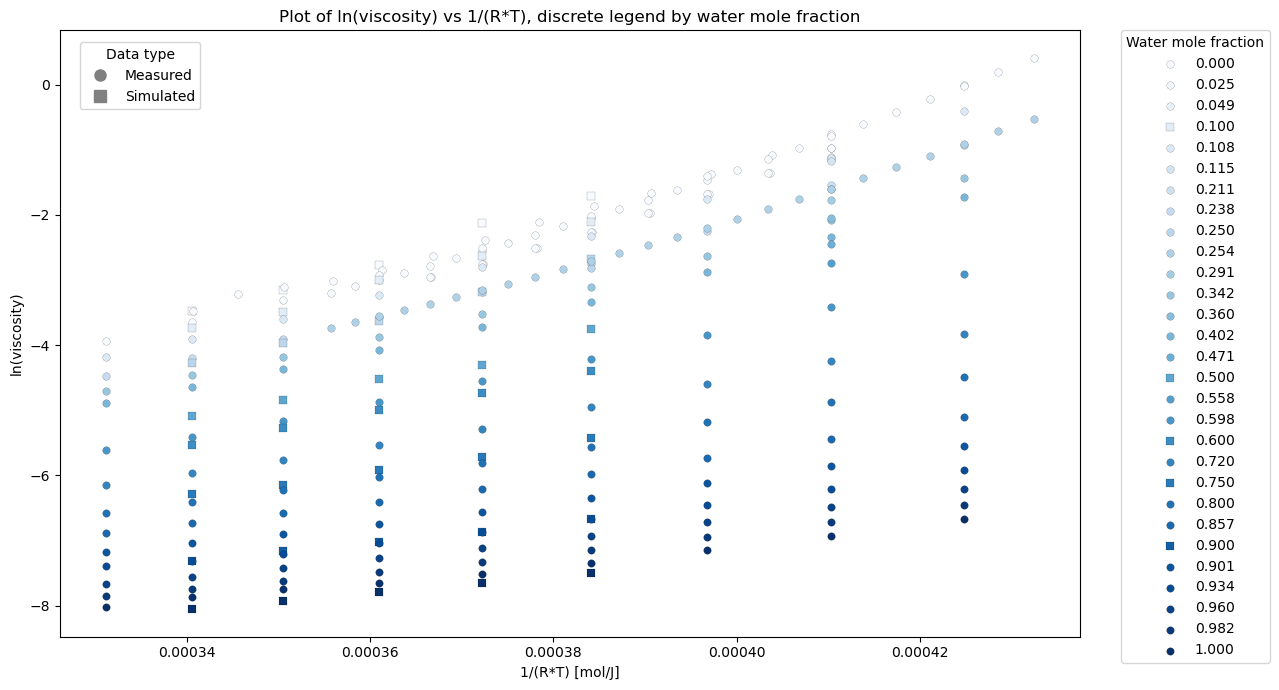

All linear fit activation energies by water mole fraction:


,water_mole_fraction,activation_energy
0,0.000,41520.682720
1,0.100,37944.135877
2,0.108,40366.403098
3,0.238,37590.289435
4,0.250,35535.117229
5,0.254,41597.359069
6,0.342,34740.693961
7,0.402,33526.414685
8,0.500,29649.374056
9,0.598,28874.286184


In [ ]:
# Make sure required columns exist
required_cols = ["viscosity_value", "temperature", "source_doi", "mole_fraction_water"]
for col in required_cols:
    if col not in combined_df.columns:
        raise ValueError(f"Column '{col}' not found in dataframe.")

# Fill missing/None values in mole_fraction_water with 0
combined_df = combined_df.copy()
combined_df["mole_fraction_water"] = (
    combined_df["mole_fraction_water"]
    .fillna(0)
    .apply(lambda x: 0 if x is None else x)
)

# Filter out rows with missing data
plot_df = combined_df[
    combined_df["viscosity_value"].notnull() &
    combined_df["temperature"].notnull() &
    combined_df["source_doi"].notnull()
].copy()

# Calculate ln(viscosity) and 1/(R*T)
R = 8.314  # J/(mol*K)
plot_df["inv_RT"] = 1 / (R * plot_df["temperature"].astype(float))
plot_df["ln_viscosity"] = np.log(plot_df["viscosity_value"].astype(float))

# Use mole_fraction_water to color the water amount
plot_df["water_mole_fraction"] = plot_df["mole_fraction_water"].astype(float)

# We'll use unique discrete values for water mole fraction as hue
plot_df["water_mole_fraction_rounded"] = plot_df["water_mole_fraction"].round(3)
discrete_mole_fractions = np.sort(plot_df["water_mole_fraction_rounded"].unique())

# Set up colormap: Blues colormap, N bins = number of unique mole fractions
N = len(discrete_mole_fractions)
cmap = cm.get_cmap('Blues', N)
color_dict = {mf: cmap(i) for i, mf in enumerate(discrete_mole_fractions)}

# Define marker shapes based on 'measured' column
marker_dict = {
    'measured': 'o',     # circle for measured
    'simulated': 's'     # square for simulated
}

plt.figure(figsize=(11,7))
ax = plt.gca()

# Scatter points for each discrete fraction and measurement type, so legend can be discrete
for i, mf in enumerate(discrete_mole_fractions):
    subset = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    
    # Group by measurement type within each mole fraction
    for measured_type in subset['measured'].unique():
        if pd.isna(measured_type):
            continue
        type_subset = subset[subset['measured'] == measured_type]
        marker = marker_dict.get(measured_type, 'o')  # default to circle if unknown type
        
        ax.scatter(
            type_subset["inv_RT"], 
            type_subset["ln_viscosity"], 
            color=color_dict[mf],
            s=30, 
            edgecolor='black',
            linewidth=0.1,
            marker=marker,
            label=f"{mf:.3f}"
        )

# Linear fit and store slopes per discrete water content
slope_results = []
for mf in discrete_mole_fractions:
    group = plot_df[plot_df["water_mole_fraction_rounded"] == mf]
    if len(group) >= 2:
        x = group["inv_RT"].values
        y = group["ln_viscosity"].values
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        xfit = np.linspace(x.min(), x.max(), 50)
        yfit = intercept + slope * xfit
        # Optional: plot the fits in same color, commented out for clarity
        # ax.plot(xfit, yfit, linestyle='--', linewidth=2, color=color_dict[mf])
        mf_tuple = tuple(group["mole_fractions"].iloc[0]) if "mole_fractions" in group.columns and isinstance(group["mole_fractions"].iloc[0], (list, tuple)) else group["mole_fractions"].iloc[0] if "mole_fractions" in group.columns else None
        slope_results.append({
            "mole_fractions": mf_tuple,
            "water_mole_fraction": float(mf),
            "slope": slope
        })

# Make discrete legend for water mole fractions
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
lgd1 = ax.legend(by_label.values(), by_label.keys(), title="Water mole fraction", bbox_to_anchor=(1.04, 1), loc='upper left', borderaxespad=0.)

# Add a second legend for marker shapes
from matplotlib.lines import Line2D
marker_legend_elements = [Line2D([0], [0], marker='o', color='gray', linestyle='None', markersize=8, label='Measured'),
                         Line2D([0], [0], marker='s', color='gray', linestyle='None', markersize=8, label='Simulated')]
lgd2 = ax.legend(handles=marker_legend_elements, title="Data type", bbox_to_anchor=(0.02, 0.98), loc='upper left', borderaxespad=0.)

# Add the first legend back
ax.add_artist(lgd1)

plt.title('Plot of ln(viscosity) vs 1/(R*T), discrete legend by water mole fraction')
plt.xlabel('1/(R*T) [mol/J]')
plt.ylabel('ln(viscosity)')
plt.tight_layout()
save_plot_as_svg()
plt.show()

import pandas as pd
activation_energy_df = pd.DataFrame(slope_results)
activation_energy_df = activation_energy_df.rename(columns={'slope': 'activation_energy'})
print("All linear fit activation energies by water mole fraction:")
display(activation_energy_df[["water_mole_fraction", "activation_energy"]])